# 02 - Feature Engineering & Spatial Enrichment (Processed Stage)

## 📌 Objective
Analyze the **Processed Level Data** (`sales_processed.parquet`). 
At this stage, we evaluate the distribution of engineered features and justify the mathematical transformations (Log Scaling) needed for model stability.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from pathlib import Path

%matplotlib inline
sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/processed/sales_processed.parquet")
print(f"🔹 Processed Sales Records: {len(df) if df is not None else 0:,}")

🔹 Processed Sales Records: 19,273


## 🔎 Deep Analysis: Skewness & Log-Transformation
Real estate data is naturally Power-Law distributed. A few ultra-luxury properties have areas and prices orders of magnitude higher than the median. 

To prevent these from dominating the MSE (Mean Squared Error) loss in our XGBoost model, we evaluate the `skewness` and apply `log1p` transformations.

--- AREA ---
Raw Skewness: 2.03
Log-Transformed Skewness: -0.17
--- PRICE ---
Raw Skewness: 2.69
Log-Transformed Skewness: -0.77


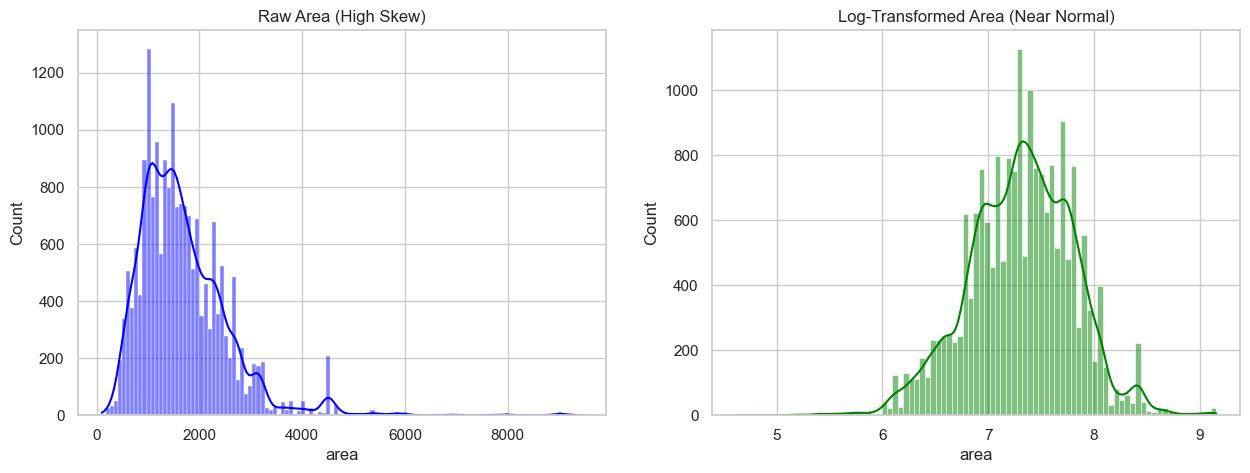

In [ ]:
if df is not None:
    features = ['area', 'price']
    for feat in features:
        s_raw = skew(df[feat].dropna())
        s_log = skew(np.log1p(df[feat].dropna()))
        
        print(f"--- {feat.upper()} ---")
        print(f"Raw Skewness: {s_raw:.2f}")
        print(f"Log-Transformed Skewness: {s_log:.2f}")
    
    # Visualizing the shift
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(df['area'], kde=True, ax=ax[0], color='blue')
    ax[0].set_title("Raw Area (High Skew)")
    
    sns.histplot(np.log1p(df['area']), kde=True, ax=ax[1], color='green')
    ax[1].set_title("Log-Transformed Area (Near Normal)")
    plt.show()

## 🔎 Deep Analysis: Spatial Prior Success (`h3_median_price`)
Our central engineering hypothesis is that neighborhood price medians are the strongest predictor.

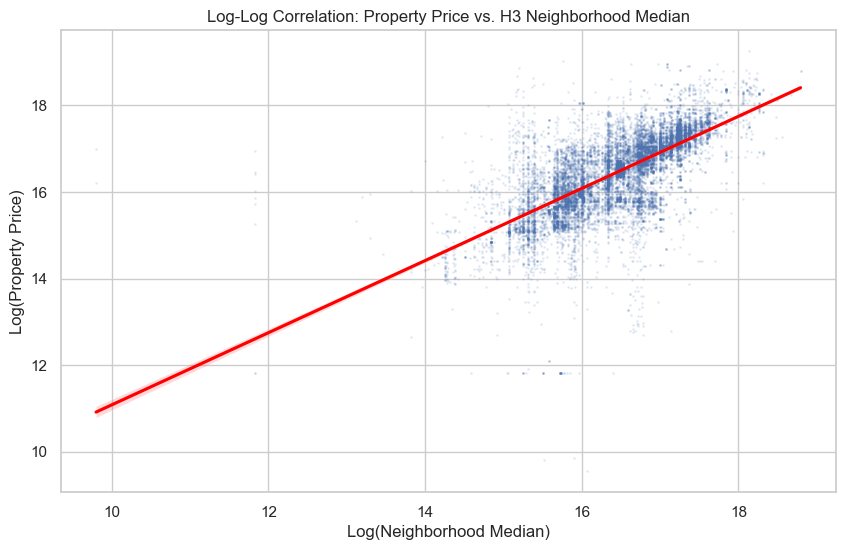

In [ ]:
if df is not None and 'h3_median_price' in df.columns:
    # Scatter Plot of Price vs Neighborhood Median
    plt.figure(figsize=(10, 6))
    # Use log-log for clarity due to extreme values
    sns.regplot(x=np.log1p(df['h3_median_price']), y=np.log1p(df['price']), 
                scatter_kws={'alpha':0.1, 's':1}, line_kws={'color':'red'})
    plt.title("Log-Log Correlation: Property Price vs. H3 Neighborhood Median")
    plt.xlabel("Log(Neighborhood Median)")
    plt.ylabel("Log(Property Price)")
    plt.show()